In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
lloyds_main = pd.read_excel("Llyods.xlsx", sheet_name= None)

In [4]:
customer_demographics = lloyds_main["Customer_Demographics"]

In [5]:
customer_demographics.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [6]:
transaction_history = lloyds_main["Transaction_History"]

In [8]:
transaction_history.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [9]:
customer_service = lloyds_main["Customer_Service"]

In [10]:
customer_service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [11]:
online_activity = lloyds_main["Online_Activity"]

In [12]:
online_activity.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [13]:
churn_status = lloyds_main["Churn_Status"]

In [14]:
churn_status.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [17]:
print(customer_demographics.isna().sum(), transaction_history.isna().sum(), customer_service.isna().sum(), online_activity.isna().sum(), churn_status.isna().sum())

CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64 CustomerID         0
TransactionID      0
TransactionDate    0
AmountSpent        0
ProductCategory    0
dtype: int64 CustomerID          0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
dtype: int64 CustomerID        0
LastLoginDate     0
LoginFrequency    0
ServiceUsage      0
dtype: int64 CustomerID     0
ChurnStatus    0
dtype: int64


Merging the Churn Status and the Online Activity together

In [28]:
customer_activity = online_activity.merge(churn_status, on="CustomerID", how="left")

In [29]:
customer_activity.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,2023-10-21,34,Mobile App,0
1,2,2023-12-05,5,Website,1
2,3,2023-11-15,3,Website,0
3,4,2023-08-25,2,Website,0
4,5,2023-10-27,41,Website,0


In [30]:
customer_information = customer_activity.merge(customer_demographics, on="CustomerID", how="left")

In [31]:
customer_information.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,Age,Gender,MaritalStatus,IncomeLevel
0,1,2023-10-21,34,Mobile App,0,62,M,Single,Low
1,2,2023-12-05,5,Website,1,65,M,Married,Low
2,3,2023-11-15,3,Website,0,18,M,Single,Low
3,4,2023-08-25,2,Website,0,21,M,Widowed,Low
4,5,2023-10-27,41,Website,0,21,M,Divorced,Medium


In [32]:
customer_service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


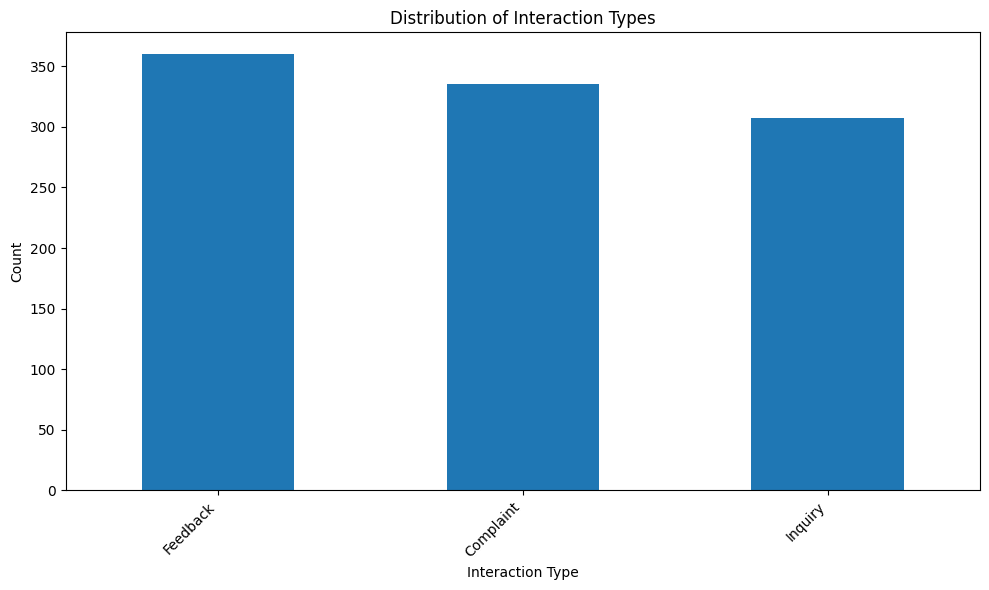

In [39]:
interaction_type_counts = customer_service['InteractionType'].value_counts()

plt.figure(figsize=(10, 6))
interaction_type_counts.plot(kind='bar')
plt.title('Distribution of Interaction Types')
plt.xlabel('Interaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

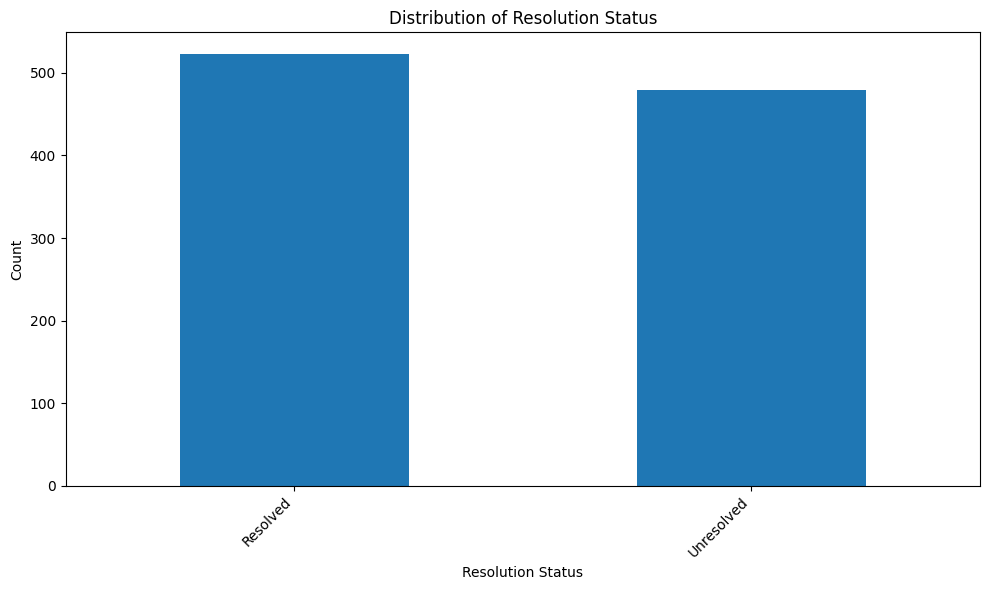

In [40]:
interaction_type_counts = customer_service['ResolutionStatus'].value_counts()

plt.figure(figsize=(10, 6))
interaction_type_counts.plot(kind='bar')
plt.title('Distribution of Resolution Status')
plt.xlabel('Resolution Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
transaction_history.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing
